# Assignment: Box Annotation Conversion to YOLO

Bounding box annotation formats are crucial in computer vision because they define how objects are located and recognized within images. These formats, typically specifying coordinates and dimensions, enable accurate training of models for tasks like object detection and tracking. By standardizing how annotations are made, they ensure consistency across datasets, facilitating model training and evaluation. This standardization enhances the efficiency and effectiveness of developing and deploying computer vision applications across various industries.


In this assignment, you are required to convert annotations from **COCO format** (a very standard data format when it comes to tasks such as object detecction, instance segmentation, pose estimation, etc.) to its corresponding **YOLO format**, again a very popular annotation format in object detection tasks.

## <font style="color:rgb(50,120,230)">Marking scheme</font>

### Maximum Points: 30

<div>
    <table>
        <tr style="text-align: center;"><td><h3><strong>Section</strong></h3></td> <td><h3><strong>Problem</strong></h3></td> <td><h3><strong>Points</strong></h3></td></tr>
        <tr><td><h3>1</h3></td> <td><h3>Mapping annotations to Image IDs</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>2</h3></td> <td><h3>Bounding Box Annotation Conversion to YOLO</h3></td> <td><h3>20</h3></td> </tr>
    </table>
</div>

In [1]:
import random
import os
import pprint

import numpy as np
import json

import cv2
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
bold = "\033[1m"
reset = "\033[0m"

In [3]:
DIR_PATH = "../data"

**COCO** is a large-scale object detection, segmentation, and captioning dataset. 

So **json** files are the working format being used for the evaluation tasks for COCO. The bounding boxes annotations are represented as: 

$$[x_{min}, y_{min}, width, height]$$

where $x_{min}$ and $y_{min}$ are the top left coordinates of the bounding boxes.

We shall use a similar format for this assignment.


We will now load the json file **`annotations_coco.json`** containing the annotations in **COCO** format.

In [4]:
with open(os.path.join(DIR_PATH, "annotations_coco.json"), "r") as f:
    json_data = json.load(f)

The variable `json_data` is a dictionary with the keys as: **`info`**, **`licenses`**, **`categories`**, **`images`** and **`annotations`**. However, the primary attributes that we will be dealing thorughout this assignment are: **`categories`**, **`images`** and **`annotations`**.

Let us try to observe these fields one by one. We will start with the `images` field.

In [5]:
print(f"{bold}Image Info:{reset}\n\n{pprint.pformat(json_data['images'],sort_dicts=False)}")

Image Info:

[{'id': 0,
  'license': 1,
  'file_name': 'test-image-3.jpg',
  'height': 960,
  'width': 640,
  'date_captured': '2024-03-05T07:56:23+00:00'},
 {'id': 1,
  'license': 1,
  'file_name': 'test-image-4.jpg',
  'height': 1896,
  'width': 1280,
  'date_captured': '2024-03-05T07:56:23+00:00'},
 {'id': 2,
  'license': 1,
  'file_name': 'test-image-1.jpg',
  'height': 959,
  'width': 640,
  'date_captured': '2024-03-05T07:56:23+00:00'},
 {'id': 3,
  'license': 1,
  'file_name': 'test-image-2.jpg',
  'height': 1600,
  'width': 1280,
  'date_captured': '2024-03-05T07:56:23+00:00'}]


You can see that the `images` key maps to a list of dictionaries where each image is associated with its corresponding meta data. The important atrributes for each image data are:
- `id`: The Image ID.
- `file_name`: The image file name.
- `height`: The image height.
- `width`: The image width.

Let us now explore the `categories` field by running the code cell below.

In [6]:
print(f"{bold}Categories Info:{reset}\n\n{pprint.pformat(json_data['categories'])}")

Categories Info:

[{'id': 0, 'name': 'person-dog-horse-umbrella', 'supercategory': 'none'},
 {'id': 1, 'name': 'dog', 'supercategory': 'person-dog-horse-umbrella'},
 {'id': 2, 'name': 'horse', 'supercategory': 'person-dog-horse-umbrella'},
 {'id': 3, 'name': 'person', 'supercategory': 'person-dog-horse-umbrella'},
 {'id': 4, 'name': 'umbrella', 'supercategory': 'person-dog-horse-umbrella'}]


Again, the `categories` field maps to a list of dictionaries where each category (or class) is associated with an ID. We won't consider `class ID = 0` since it maps with the super-category (encompassing all the classes in the data).

Finally, we shall explore the `annotation` field as shown below.

In [7]:
print(f"{bold}Annotations Info:{reset}\n\n{pprint.pformat(json_data['annotations'][:6], sort_dicts=False)}")

Annotations Info:

[{'id': 0,
  'image_id': 0,
  'category_id': 3,
  'bbox': [135, 484, 120.91, 343.64],
  'area': 41549.512,
  'segmentation': [],
  'iscrowd': 0},
 {'id': 1,
  'image_id': 0,
  'category_id': 1,
  'bbox': [189, 714, 78.18, 115.45],
  'area': 9025.881,
  'segmentation': [],
  'iscrowd': 0},
 {'id': 2,
  'image_id': 0,
  'category_id': 3,
  'bbox': [354, 443, 130, 374.55],
  'area': 48691.5,
  'segmentation': [],
  'iscrowd': 0},
 {'id': 3,
  'image_id': 0,
  'category_id': 4,
  'bbox': [275, 387, 220.91, 178.18],
  'area': 39361.744,
  'segmentation': [],
  'iscrowd': 0},
 {'id': 4,
  'image_id': 0,
  'category_id': 1,
  'bbox': [271, 657, 147.27, 177.27],
  'area': 26106.553,
  'segmentation': [],
  'iscrowd': 0},
 {'id': 5,
  'image_id': 1,
  'category_id': 3,
  'bbox': [192, 1002, 244, 640],
  'area': 156160,
  'segmentation': [],
  'iscrowd': 0}]


Each annotated instance has the following attributes:
* `id`: The annotation ID.
* `image_id`: The image (image ID) which the particular annotation belongs to.
* `category_id`: The class ID of the annotation.
* `bbox`: The bounding box annotation in `[xmin, ymin, width, height]` format.
* `area`: The bounding box area.
* `segmenatation`: The segmentation mask pixels in polygon (x-y pairs) or in RLE format. **We don't require this attribute for the assignment.**
* `iscrowd`: flag to indicate whether the annotation is for single object or group of objects.


**Note:** We have shown only a subset of the total annotation instances across the images.

## 1 Map annotations to Image IDs [10 Points]

In this section, your task is to map the `image_id` with its corresponding bounding boxes (and the appropriate category IDs); so that each image consists of all the bounding boxes associated with it.

It should return a dictionary which has the keys as `image_id` and values as a dictionary mappings from the category ID to a list of all the bounding boxes associated with it.

The dictionary returned by the `map_image_to_anns` function should be in the following format:

```python
{ImageID_1: {CatID_1: [b_1, b_2, ..., b_m],
             CatID_2: [b_1, b_2, ..., b_n],
             ...
             ...},

 ImageID_2: {CatID_1: [b_1, b_2, ..., b_k],
             CatID_2: [b_1, b_2, ..., b_l],
             ...
             ...},
 ...
 ...
}
```

where, $b_{i}$ is a list containing the coordinates of the $i^{th}$ bounding box in **COCO** (`[xmin, ymin, width, height]`) format.

**Note:** 
- Its **not** necessary for an Image ID to contain all the categories.
- Even for a singleton bbox annotation for a particular category, the category mapping should be a list of lists.
    * Example: `{3: [[295, 243, 250, 563.64]]}`

**Hint:** You can use the **`annotations`** attribute for generating the mapping.

In [8]:
def map_image_to_anns(data: dict[str, dict|list[dict]]):
    
    """
    :param: data: Dict containing bbox annotations.
                  Keys: `info`, `licenses`, `categories`, `images` and `annotations`
                  
    Returns:
    `image_ann_mapping`: a dict mapping from ImageID to annotations
                
    """
    
    image_ann_mapping = dict()
    
    ###
    ### YOUR CODE HERE
    uniq_img_id = sorted(list(set(d['image_id'] for d in data['annotations'])))

    for img_id in uniq_img_id:
        img = [[d['category_id'], d['bbox']] for d in data['annotations'] if d['image_id'] == img_id]
        uniq_cat = sorted(list(set(i[0] for i in img)))
        sub_parent_dict = {i: [] for i in uniq_cat}
        for d in data['annotations']:
            if d['image_id'] == img_id:
                sub_parent_dict[d['category_id']].append(d['bbox'])
        image_ann_mapping[img_id] = sub_parent_dict   
    ###

    return image_ann_mapping

**Running the code cell below should generate the following output.**

```python
The mapped data:

{0: {1: [[189, 714, 78.18, 115.45], [271, 657, 147.27, 177.27]],
     3: [[135, 484, 120.91, 343.64], [354, 443, 130, 374.55]],
     4: [[275, 387, 220.91, 178.18]]},
 1: {1: [[358, 1466, 172, 198], [668, 1388, 186, 284], [858, 1402, 156, 276]],
     3: [[192, 1002, 244, 640], [526, 1000, 228, 658]]},
 2: {1: [[155, 422, 303.64, 509.09]],
     3: [[104, 215, 159.09, 603.64], [295, 243, 250, 563.64]]},
 3: {1: [[300, 1048, 206.67, 356.67]],
     2: [[388, 417, 861.67, 1000]],
     3: [[763, 307, 268.33, 706.67]]}}
```

In [9]:
mapped_data = map_image_to_anns(json_data)

print(f"{bold}The mapped data:{reset}\n\n{pprint.pformat(mapped_data)}")

The mapped data:

{0: {1: [[189, 714, 78.18, 115.45], [271, 657, 147.27, 177.27]],
     3: [[135, 484, 120.91, 343.64], [354, 443, 130, 374.55]],
     4: [[275, 387, 220.91, 178.18]]},
 1: {1: [[358, 1466, 172, 198], [668, 1388, 186, 284], [858, 1402, 156, 276]],
     3: [[192, 1002, 244, 640], [526, 1000, 228, 658]]},
 2: {1: [[155, 422, 303.64, 509.09]],
     3: [[104, 215, 159.09, 603.64], [295, 243, 250, 563.64]]},
 3: {1: [[300, 1048, 206.67, 356.67]],
     2: [[388, 417, 861.67, 1000]],
     3: [[763, 307, 268.33, 706.67]]}}


In [10]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


## Bounding Box Annotation Conversion to YOLO [20 Points]

Before we begin with the annotation conversion, we need to structure a few things for simplying the further compuations.

Recall that the `images` field was a list of dictionaries containing the image meta data and an associated ID. We will restructure it to single dictionary mapping from the ImageID to the image attributes such as the height, width and the image file name.

The `create_image_info_map` function creates a dictionary mapping from the Image ID to a dictionary with the image `file_name`, `height` and `width` attributes. 

In [11]:
def create_image_info_map(data):
    
    image_data = dict()
    
    for im_item in data["images"]:
        image_data[im_item["id"]] = {"height":im_item["height"],
                                     "width":im_item["width"],
                                     "file_name":im_item["file_name"]}
    return image_data

We will maintain a class ID mapping with the category names and color coding.

In [12]:
# Category Names
ID_TO_CLASS = {1:"dog", 2:"horse", 3:"person", 4:"umbrella"}

# BGR color coding.
COLORS = {1:(255,102,0), 2:(0,0,204), 3:(51,153,51), 4:(0,153,255)}

In [13]:
image_info_dict = create_image_info_map(json_data)

print(f"{bold}Image Info (restructured):{reset}\n\n{pprint.pformat(image_info_dict)}")

Image Info (restructured):

{0: {'file_name': 'test-image-3.jpg', 'height': 960, 'width': 640},
 1: {'file_name': 'test-image-4.jpg', 'height': 1896, 'width': 1280},
 2: {'file_name': 'test-image-1.jpg', 'height': 959, 'width': 640},
 3: {'file_name': 'test-image-2.jpg', 'height': 1600, 'width': 1280}}


We have seen that the annotations in the dataset are of the format: `[xmin, ymin, width, height]` format. However, in order to proceed with the training we need to convert them to a format accepted by YOLO.

The bounding box annotation format across all YOLO models is:
$\mathbf{[x_{center},\ y_{center},\ width,\ height]}$, where all the coordinates are normalized in the range: `[0,1]`. We can pen down the coordinates in simple equations:

$$
\begin{align}
 x_{center-norm}  &= \frac{1}{image_{width}}\cdot\left(x_{min} + \frac{1}{2}\cdot box_{width}\right) \\
 y_{center-norm}  &= \frac{1}{image_{height}}\cdot\left(y_{min} + \frac{1}{2}\cdot box_{height}\right) \\
 box_{width-norm} &= \frac{1}{image_{width}} \cdot box_{width} \\
 box_{height-norm} &= \frac{1}{image_{height}} \cdot box_{height} \\
\end{align}
$$

The `convert_coco_to_yolo` utility will be used to convert the bounding box coordinates to the YOLO annotation format; the details of which has been described through the equations above. The box annotations for each image across all categories are passed to the function. Specifically, it takes the following arguments:

- `boxes`: A numpy array of bounding box coordinates in `[xmin, ymin, width, height]` format.
- `image_res`: The tuple (of height and width) specifying the image resolution.

In [14]:
def convert_coco_to_yolo(boxes: np.ndarray, image_res: tuple[int, int]):
    """
    :param - `boxes`: numpy array of shape (N, 4),
              where, `N` is the total # of instances for a particular image,
              the coordinates are represented in [xmin, ymin, width, height] (un-normalized)
              
           - `image_res`: a tuple specifying the image resolution as (height, width)
           
    Returns:
    `yolo_boxes`: numpy array of shape (N, 4), where coordinates are normalized in the range `[0,1]`
                  confirming to YOLO format for bounding box annotations.
    """

    yolo_boxes = None
    
    ###
    ### YOUR CODE HERE
    yolo_boxes = []
    img_width = image_res[1]
    img_height = image_res[0]
    for box in boxes:
        xmin = box[0]
        ymin = box[1]
        width = box[2]
        height = box[3]
        xmax = xmin + width
        ymax = ymin + height
        x_center = (xmin+xmax)/2
        y_center = (ymin+ymax)/2
        norm_x_center = x_center/img_width
        norm_y_center = y_center/img_height
        norm_width = width/img_width
        norm_height = height/img_height
        yolo_boxes.append([norm_x_center, norm_y_center, norm_width, norm_height])
    yolo_boxes = np.array(yolo_boxes)
    ###

    return yolo_boxes

In [15]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


We shall now use the `convert_coco_to_yolo` function to map the image IDs with box annotations and the class label. 

**Running the code cell below should yield the following output.**

```python
{0: (array([[0.30539844, 0.68314583, 0.18892187, 0.35795833],
         [0.6546875 , 0.65653646, 0.203125  , 0.39015625],
         [0.35639063, 0.80388021, 0.12215625, 0.12026042],
         [0.53849219, 0.77670312, 0.23010938, 0.18465625],
         [0.60227344, 0.49592708, 0.34517188, 0.18560417]]),
  [3, 3, 1, 1, 4]),
 1: (array([[0.2453125 , 0.69725738, 0.190625  , 0.33755274],
         [0.5       , 0.70094937, 0.178125  , 0.34704641],
         [0.346875  , 0.82542194, 0.134375  , 0.10443038],
         [0.59453125, 0.80696203, 0.1453125 , 0.14978903],
         [0.73125   , 0.81223629, 0.121875  , 0.14556962]]),
  [3, 3, 1, 1, 1]),
 2: (array([[0.28678906, 0.53891554, 0.24857813, 0.62944734],
         [0.65625   , 0.54725756, 0.390625  , 0.58773723],
         [0.47940625, 0.70546924, 0.4744375 , 0.53085506]]),
  [3, 3, 1]),
 3: (array([[0.63971484, 0.573125  , 0.67317969, 0.625     ],
         [0.31510547, 0.76645938, 0.16146094, 0.22291875],
         [0.70091016, 0.41270938, 0.20963281, 0.44166875]]),
  [2, 1, 3])}
```

In [16]:
YOLO_BOXES = dict()

for i, (im_ID, box_data) in enumerate(mapped_data.items(),1):
    im_all_boxes = []
    im_all_cats = []
    
    for cat_id, boxes in box_data.items():
        im_all_boxes.extend(boxes)
        im_all_cats.extend([cat_id]*len(boxes))

    im_all_boxes = np.array(im_all_boxes, dtype="float")
    image_res = (image_info_dict[im_ID]["height"], image_info_dict[im_ID]["width"])

    image_yolo_boxes = convert_coco_to_yolo(im_all_boxes, image_res)
    YOLO_BOXES[im_ID] = (image_yolo_boxes,  im_all_cats)


print(f"{bold}The Box annotations in YOLO:{reset}\n\n{pprint.pformat(YOLO_BOXES)}")

The Box annotations in YOLO:

{0: (array([[0.35639063, 0.80388021, 0.12215625, 0.12026042],
       [0.53849219, 0.77670312, 0.23010938, 0.18465625],
       [0.30539844, 0.68314583, 0.18892187, 0.35795833],
       [0.6546875 , 0.65653646, 0.203125  , 0.39015625],
       [0.60227344, 0.49592708, 0.34517188, 0.18560417]]),
     [1, 1, 3, 3, 4]),
 1: (array([[0.346875  , 0.82542194, 0.134375  , 0.10443038],
       [0.59453125, 0.80696203, 0.1453125 , 0.14978903],
       [0.73125   , 0.81223629, 0.121875  , 0.14556962],
       [0.2453125 , 0.69725738, 0.190625  , 0.33755274],
       [0.5       , 0.70094937, 0.178125  , 0.34704641]]),
     [1, 1, 1, 3, 3]),
 2: (array([[0.47940625, 0.70546924, 0.4744375 , 0.53085506],
       [0.28678906, 0.53891554, 0.24857813, 0.62944734],
       [0.65625   , 0.54725756, 0.390625  , 0.58773723]]),
     [1, 3, 3]),
 3: (array([[0.31510547, 0.76645938, 0.16146094, 0.22291875],
       [0.63971484, 0.573125  , 0.67317969, 0.625     ],
       [0.70091016, 0.4127

From the results above, you can that `YOLO_BOXES` is a dictionary mapping of the Image IDs (keys) and their annotations. Each value represents a tuple where the first item represents the bbox annotaions and the second being the class IDs.

### Conversion from YOLO to PASCAL VOC

Once we have converted the annotations to the appropriate format, we can convert them back to absolute coordinates. We can consider this step as a cross-verification step just to ensure that the conversion was carried out correctly.

The `convert_yolo_to_voc` utility is used to transform the YOLO annotations to the VOC format in absolute coordinates (`[xmin, ymin, xmax, ymax]`).

We already have this implemented for you.

In [17]:
def convert_yolo_to_voc(yolo_boxes, image_res):
    
    voc_boxes = np.empty(shape=yolo_boxes.shape)

    im_res_array = np.array([image_res[1], image_res[0], image_res[1], image_res[0]])
    
    voc_boxes[:,:2] = yolo_boxes[:,:2] - 0.5*yolo_boxes[:,2:]
    voc_boxes[:,2:] = yolo_boxes[:,:2] + 0.5*yolo_boxes[:,2:]
    
    voc_boxes = (voc_boxes * im_res_array).clip(min=[0.,0.,0.,0.],
                                          max=[image_res[1]-1, image_res[0]-1, image_res[1]-1, image_res[0]-1])

    return voc_boxes.tolist()

## Annotation Visualization

The `draw_bbox` utility is used to plot the annotations given a particular format (`COCO` or `VOC`).

In [18]:
def draw_bbox(image, boxes, class_IDs, format="COCO", thickness=-1):

    overlay = image.copy()

    font_size = 0.25 + 0.07 * min(overlay.shape[:2]) / 100
    font_size = max(font_size, 0.5)
    font_size = min(font_size, 0.8)
    text_offset = 7

    for box, clsID in zip(boxes, class_IDs):
        xmin = int(box[0])
        ymin = int(box[1])

        if format=="COCO":
            xmax = int(box[0]+box[2])
            ymax = int(box[1]+box[3])

        elif format=="VOC":
            xmax = int(box[2])
            ymax = int(box[3])

        else:
            raise ValueError("Format should be either 'COCO' or 'VOC'.")
        
        overlay = cv2.rectangle(overlay, (xmin, ymin), (xmax, ymax), COLORS[clsID], thickness)

        display_text = f"{ID_TO_CLASS[clsID]}"

        (text_width, text_height), _ = cv2.getTextSize(display_text, cv2.FONT_HERSHEY_SIMPLEX, font_size, 2)

        cv2.rectangle(overlay,
                      (xmin, ymin),
                      (xmin + text_width + text_offset, ymin - text_height - int(15 * font_size)),
                      COLORS[clsID], thickness=-1)


        overlay = cv2.putText(
                    overlay,
                    display_text,
                    (xmin + text_offset, ymin - int(10 * font_size)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    font_size,
                    (255, 255, 255),
                    2, lineType=cv2.LINE_AA,
                )

    return cv2.addWeighted(overlay, 0.75, image, 0.25, 0)

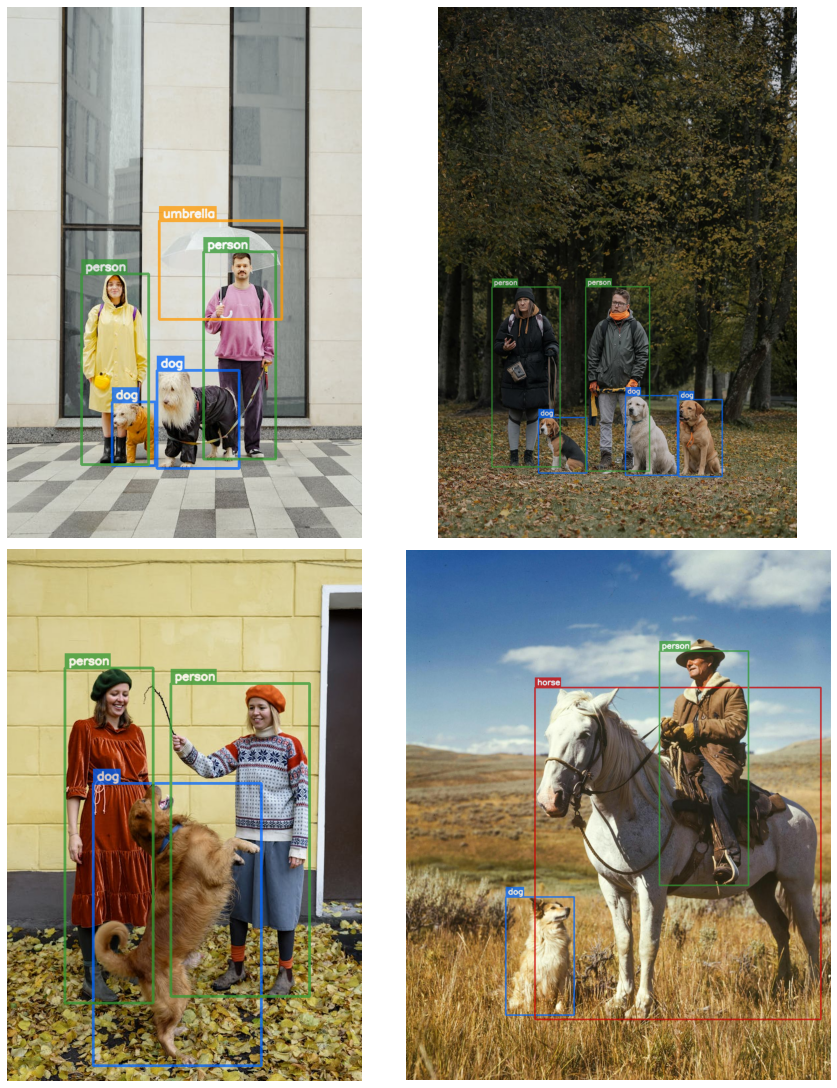

In [19]:
fig = plt.figure(figsize=(12, 15), constrained_layout=True)

for i, (im_ID, box_data) in enumerate(YOLO_BOXES.items(),1):

    image = cv2.imread(os.path.join(DIR_PATH, image_info_dict[im_ID]["file_name"]))

    abs_boxes = convert_yolo_to_voc(box_data[0], image.shape[:2])

    image_ann = draw_bbox(image, abs_boxes, box_data[1], format="VOC", thickness=3)

    ax = plt.subplot(2, 2, i)
    plt.imshow(image_ann[..., ::-1])
    plt.axis("off")
  
plt.show()